In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是黑体的字体名称
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

In [2]:
def conv_2d_fn(image,kernel):
    h,w = image.shape
    kernel_h,kernel_w = kernel.shape
    new_h = h - kernel_h + 1
    new_w = w - kernel_w + 1
    
    new_image = np.zeros((new_h,new_w))
    
    for i in range(new_h):
        for j in range(new_w):
            compu_region = image[i:i+kernel_h,j:j+kernel_w]
            new_image[i][j] = np.sum(compu_region*kernel)
    return new_image

In [3]:
def convolve2d(image, kernel):
    """
    Perform 2D convolution operation on an image with a kernel.
    
    Parameters:
    image (np.array): The input 2D image.
    kernel (np.array): The 2D convolution kernel.
    
    Returns:
    np.array: The convolved image.
    """
    # 获取图像和核的尺寸
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    # 计算输出图像的尺寸
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1
    
    # 初始化输出图像
    output = np.zeros((output_height, output_width))
    
    
    # 进行卷积操作
    for i in range(output_height):
        for j in range(output_width):
            # 提取图像的局部区域
            image_region = image[i:i+kernel_height, j:j+kernel_width]
            
            # 计算卷积和
            output[i, j] = np.sum(image_region * kernel)
    
    return output

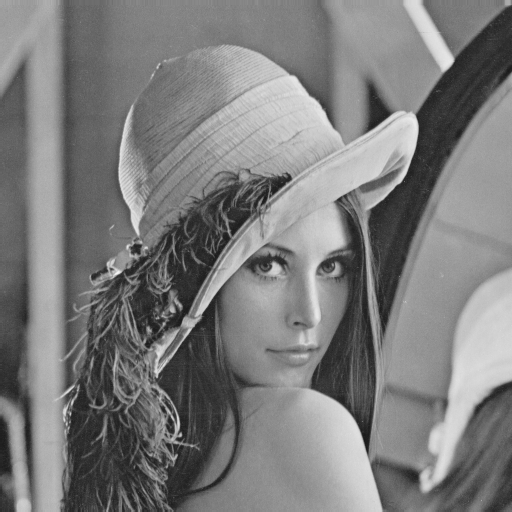

In [5]:
kernel1 = np.array([[0,-1,0],
                  [-1,4,-1],
                  [0,-1,0]])

kernel2 = np.array([[-1,-1,-1],
                  [-1,8,-1],
                  [-1,-1,-1]])
image = Image.open('lena.bmp')
image_gray = image.convert("L")
image_gray

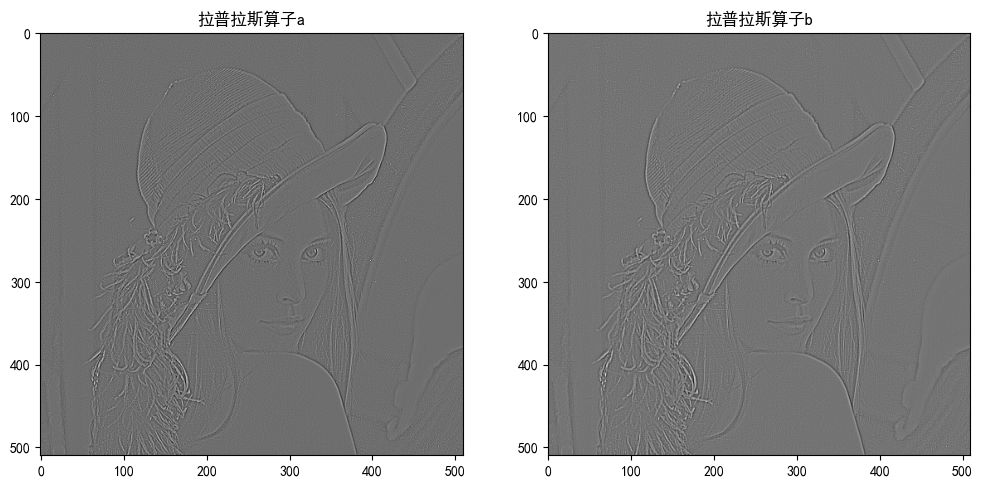

In [6]:
image_array = np.array(image_gray)

conv_image1 = conv_2d_fn(image_array,kernel1)
conv_image2 = convolve2d(image_array,kernel2)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(conv_image1,cmap='gray')
plt.title('拉普拉斯算子a')

plt.subplot(1,2,2)
plt.imshow(conv_image2,cmap='gray')
plt.title('拉普拉斯算子b')
plt.show()

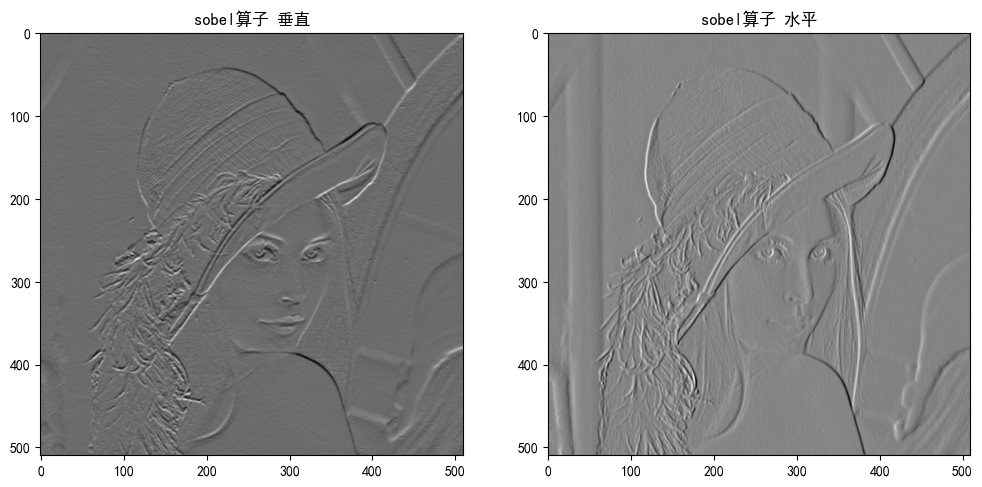

In [7]:
sobel_kernel_hor = np.array([[1,2,1],
                        [0,0,0],
                        [-1,-2,-1]])
sobel_kernel_ver = np.array([[-1,0,1],
                            [-2,0,2],
                            [-1,0,1]])
conv_image3 = convolve2d(image_array,sobel_kernel_hor)
conv_image4 = convolve2d(image_array,sobel_kernel_ver)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(conv_image3,cmap='gray')
plt.title('sobel算子 垂直')

plt.subplot(1,2,2)
plt.imshow(conv_image4,cmap='gray')
plt.title('sobel算子 水平')
plt.show()

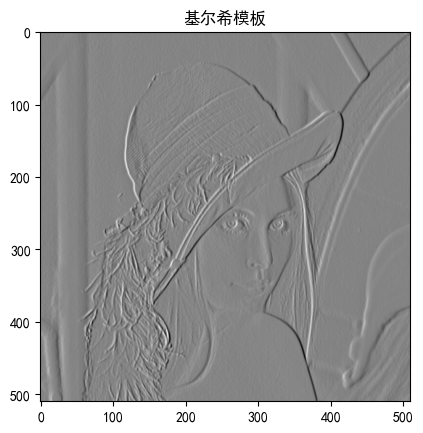

In [8]:
kernel_kirsch = np.array([[-5,3,3],
                         [-5,0,3],
                         [-5,3,3]])
conv_image5 = convolve2d(image_array,kernel_kirsch)
plt.imshow(conv_image4,cmap='gray')
plt.title('基尔希模板')
plt.show()